# Modelos — Etapa 1: Baselines

Pipeline: EDA → limpeza de tipos → tratamento de "No service" → features derivadas → split treino/teste → fit do encoder+scaler no treino → transform em ambos → **baseline (Dummy + LR)**

Métricas avaliadas:
- **Técnicas**: Accuracy, F1-Score, Precision, Recall, ROC-AUC, PR-AUC
- **Negócio**: Custo de churn evitado (TP), custo falso positivo (FP), churn perdido (FN), lucro líquido

## Setup

In [1]:
import pandas as pd
import numpy as np
import random
import hashlib
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from utils import preprocessing, prepare_train_val_test

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TEST_SIZE = 0.2

## Carregamento e Pré-processamento

In [2]:
DATASET_PATH = "../data/dataset/telco_customer_churn.csv"

df_raw = pd.read_csv(DATASET_PATH)
df = df_raw.copy()
df.rename(columns={"Churn": "target"}, inplace=True)
df["target"] = df["target"].map({"Yes": 1, "No": 0})

# Versionamento do dataset
with open(DATASET_PATH, "rb") as f:
    DATASET_VERSION = hashlib.md5(f.read()).hexdigest()
print(f"Dataset MD5: {DATASET_VERSION}")
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True).round(4)}")

Dataset MD5: 0f9de68e012bd3aed5fa7cdc9fc421af
Shape: (7043, 21)
Target distribution:
target
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [3]:
# Pré-processamento: limpeza, encoding, features derivadas (conforme docs/feature-engineering.md)
df_encoded = preprocessing(df)

# Split treino/teste com StandardScaler (mode='baseline' → sem validation set)
X_train, X_test, y_train, y_test = prepare_train_val_test(
    df_encoded, test_size=TEST_SIZE, random_state=SEED, mode="baseline"
)

print(f"Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Target rate (treino): {y_train.mean():.4f}")

Colunas categóricas (3): ['Contract', 'PaymentMethod', 'tenure_bucket']

  Contract: 3 valores únicos → ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: 4 valores únicos → ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  tenure_bucket: 4 valores únicos → ['0-12', '25-48', '13-24', '49+']
Categories (4, object): ['0-12' < '13-24' < '25-48' < '49+']
Treino: 5634 amostras, 22 features
Teste:  1409 amostras
Target rate (treino): 0.2654


## Função de Avaliação

Métricas técnicas + duas métricas de negócio complementares:

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| LTV por cliente retido (TP) | R$ 500 | Receita preservada ao reter um cliente que churaria |
| Custo de retenção (TP + FP) | R$ 100 | Custo da campanha/desconto oferecido |

| Métrica de negócio | Fórmula | Pergunta que responde |
|--------------------|---------|----------------------|
| **ROI Campanha** | `ganho_tp - custo_fp` | "A campanha de retenção se paga?" |
| **Lucro Líquido** | `ganho_tp - custo_fp - perda_fn` | "Qual o impacto econômico total de usar este modelo?" |

In [4]:
VALOR_CLIENTE_LTV = 500  # Ganho ao reter um TP
CUSTO_RETENCAO = 100     # Custo da oferta (desconto/cupom) para TP e FP


def evaluate_model(model, X_test, y_test):
    """Avalia modelo com métricas técnicas e de negócio. Retorna dict de métricas e confusion matrix."""
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = np.zeros(len(y_test))

    # Métricas técnicas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1)
    roc = roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5
    pr_prec, pr_rec, _ = precision_recall_curve(y_test, y_proba)
    pr = auc(pr_rec, pr_prec)

    # Métricas de negócio
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ganho_tp = tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO)
    custo_fp = fp * CUSTO_RETENCAO
    perda_fn = fn * VALOR_CLIENTE_LTV
    roi_campanha = ganho_tp - custo_fp                  # ROI da acao de retencao
    lucro_liquido = ganho_tp - custo_fp - perda_fn      # Impacto economico total do modelo

    metrics = {
        "accuracy": acc,
        "f1_score": f1,
        "precision": prec,
        "recall": rec,
        "roc_auc": roc,
        "pr_auc": pr,
        "custo_churn_evitado_BRL": ganho_tp,
        "custo_falso_positivo_BRL": custo_fp,
        "custo_churn_perdido_BRL": perda_fn,
        "roi_campanha_BRL": roi_campanha,
        "lucro_liquido_BRL": lucro_liquido,
    }

    # Print resumo
    print(classification_report(y_test, y_pred, target_names=["Sem churn", "Com churn"]))
    print(f"  ROC-AUC:  {roc:.4f}")
    print(f"  PR-AUC:   {pr:.4f}")
    print(f"  TP Custo churn evitado:  R$ {ganho_tp:,.0f}")
    print(f"  FN Custo churn perdido:  R$ {perda_fn:,.0f}")
    print(f"  FP Custo falso positivo: R$ {custo_fp:,.0f}")
    print(f"  ROI Campanha:            R$ {roi_campanha:,.0f}  (ganho_tp - custo_fp)")
    print(f"  Lucro Liquido:           R$ {lucro_liquido:,.0f}  (ganho_tp - custo_fp - perda_fn)")

    return metrics, cm

## Baseline 1: DummyClassifier

Baseline ingênuo — sempre prediz a classe majoritária (`most_frequent`). Serve como piso: qualquer modelo real precisa superar isso.

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)

print("=" * 60)
print(" DummyClassifier (most_frequent)")
print("=" * 60)
dummy_metrics, dummy_cm = evaluate_model(dummy, X_test, y_test)

 DummyClassifier (most_frequent)
              precision    recall  f1-score   support

   Sem churn       0.73      1.00      0.85      1035
   Com churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

  ROC-AUC:  0.5000
  PR-AUC:   0.6327
  TP Custo churn evitado:  R$ 0
  FN Custo churn perdido:  R$ 187,000
  FP Custo falso positivo: R$ 0
  ROI Campanha:            R$ 0  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ -187,000  (ganho_tp - custo_fp - perda_fn)


## Baseline 2: Regressão Logística

Baseline com `class_weight='balanced'` para compensar o desbalanceamento (~26% churn). Usa solver `lbfgs` com `max_iter=1000`.

In [6]:
lr = LogisticRegression(
    max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
)
lr.fit(X_train, y_train)

print("=" * 60)
print(" LogisticRegression (balanced)")
print("=" * 60)
lr_metrics, lr_cm = evaluate_model(lr, X_test, y_test)

 LogisticRegression (balanced)
              precision    recall  f1-score   support

   Sem churn       0.91      0.73      0.81      1035
   Com churn       0.51      0.80      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

  ROC-AUC:  0.8473
  PR-AUC:   0.6660
  TP Custo churn evitado:  R$ 119,200
  FN Custo churn perdido:  R$ 38,000
  FP Custo falso positivo: R$ 28,200
  ROI Campanha:            R$ 91,000  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 53,000  (ganho_tp - custo_fp - perda_fn)


## Comparacao Visual

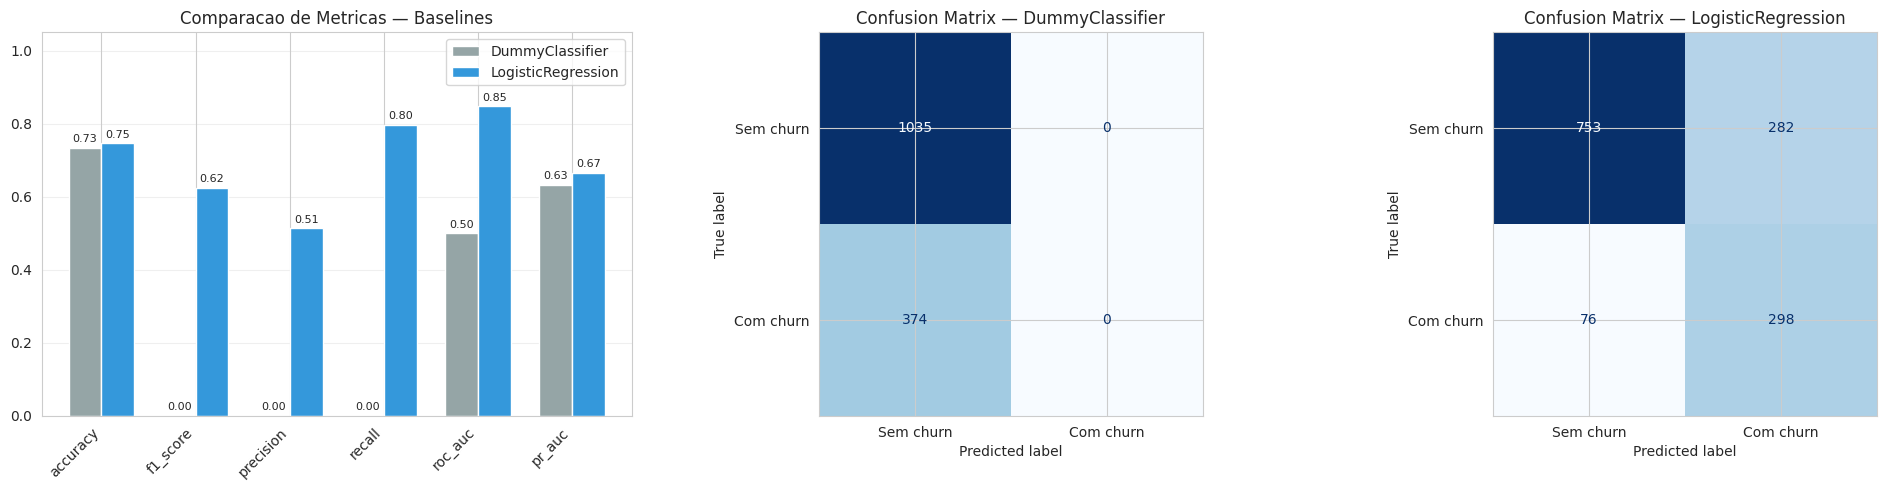

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- 1. Métricas lado a lado ---
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35
bars1 = axes[0].bar(x - width / 2, dummy_vals, width, label="DummyClassifier", color="#95a5a6")
bars2 = axes[0].bar(x + width / 2, lr_vals, width, label="LogisticRegression", color="#3498db")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparacao de Metricas — Baselines")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8,
    )
for bar in bars2:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8,
    )

# --- 2. Confusion Matrix — Dummy ---
ConfusionMatrixDisplay(dummy_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("Confusion Matrix — DummyClassifier")

# --- 3. Confusion Matrix — LR ---
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("Confusion Matrix — LogisticRegression")

plt.tight_layout()
plt.show()

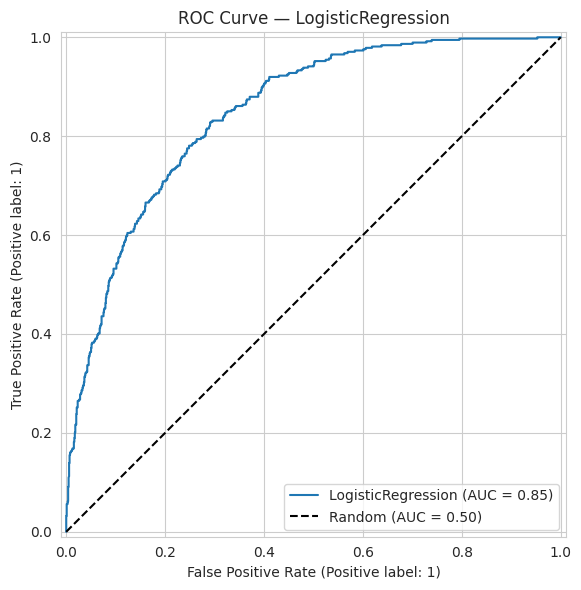

In [8]:
# ROC Curve — somente LR (Dummy com most_frequent não tem curva informativa)
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name="LogisticRegression")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — LogisticRegression")
ax.legend()
plt.tight_layout()
plt.show()

## Resumo dos Baselines

In [9]:
all_metrics = list(dummy_metrics.keys())
resumo = pd.DataFrame({
    "Metrica": all_metrics,
    "DummyClassifier": [dummy_metrics[m] for m in all_metrics],
    "LogisticRegression": [lr_metrics[m] for m in all_metrics],
})

# Formatar valores monetários
for col in ["DummyClassifier", "LogisticRegression"]:
    resumo[col] = resumo.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

print("=" * 60)
print(" RESUMO DOS BASELINES")
print("=" * 60)
resumo

 RESUMO DOS BASELINES


,Metrica,DummyClassifier,LogisticRegression
0,accuracy,0.7346,0.7459
1,f1_score,0.0000,0.6247
2,precision,0.0000,0.5138
3,recall,0.0000,0.7968
4,roc_auc,0.5000,0.8473
5,pr_auc,0.6327,0.6660
6,custo_churn_evitado_BRL,R$ 0,"R$ 119,200"
7,custo_falso_positivo_BRL,R$ 0,"R$ 28,200"
8,custo_churn_perdido_BRL,"R$ 187,000","R$ 38,000"
9,roi_campanha_BRL,R$ 0,"R$ 91,000"


## Etapa 2: MLP (PyTorch)

**Objetivo**: superar os baselines (especialmente a Regressão Logística) com uma rede neural MLP.

**Arquitetura escolhida**:
- 3 camadas ocultas com BatchNorm + ReLU + Dropout
- Dimensões decrescentes: 128 → 64 → 32
- Loss: BCEWithLogitsLoss com `pos_weight` para compensar desbalanceamento
- Otimizador: Adam com weight decay (regularização L2)
- Early stopping no validation loss (paciência = 15 épocas)

**Justificativa**:
- BatchNorm estabiliza o treinamento e acelera convergência
- Dropout (0.3) previne overfitting em dataset pequeno (~5.6k treino)
- `pos_weight` compensa o desbalanceamento 73/27 sem precisar de oversampling
- Arquitetura decrescente (funil) força compressão progressiva das representações

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reprodutibilidade PyTorch
torch.manual_seed(SEED)

# Forçar CPU (versão do PyTorch sem kernels compatíveis com esta GPU)
device = torch.device("cpu")
print(f"Device: {device}")

Device: cpu


### Preparação dos dados (com validation set)

In [11]:
# Re-split com validation set para early stopping
X_train_mlp, X_val_mlp, X_test_mlp, y_train_mlp, y_val_mlp, y_test_mlp = prepare_train_val_test(
    df_encoded, test_size=TEST_SIZE, random_state=SEED, mode="mlp"
)

print(f"Treino:     {X_train_mlp.shape[0]} amostras, {X_train_mlp.shape[1]} features")
print(f"Validação:  {X_val_mlp.shape[0]} amostras")
print(f"Teste:      {X_test_mlp.shape[0]} amostras")
print(f"Target rate (treino): {y_train_mlp.mean():.4f}")

# pos_weight para BCEWithLogitsLoss
n_pos = y_train_mlp.sum()
n_neg = len(y_train_mlp) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight.item():.2f} (neg/pos = {n_neg}/{n_pos})")

Treino:     4507 amostras, 22 features
Validação:  1127 amostras
Teste:      1409 amostras
Target rate (treino): 0.2654
pos_weight: 2.77 (neg/pos = 3311/1196)


In [12]:
# Converter para tensores PyTorch
def to_tensors(X, y):
    return (
        torch.tensor(X.values.astype(np.float32), dtype=torch.float32),
        torch.tensor(y.values.astype(np.float32), dtype=torch.float32),
    )

X_train_t, y_train_t = to_tensors(X_train_mlp, y_train_mlp)
X_val_t, y_val_t = to_tensors(X_val_mlp, y_val_mlp)
X_test_t, y_test_t = to_tensors(X_test_mlp, y_test_mlp)

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False
)

print(f"Batches — treino: {len(train_loader)}, val: {len(val_loader)}, teste: {len(test_loader)}")

Batches — treino: 71, val: 18, teste: 23


### Definição da Arquitetura MLP

In [13]:
class ChurnMLP(nn.Module):
    """MLP para predição de churn com BatchNorm e Dropout."""

    def __init__(self, input_dim, hidden_dims=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))  # saída logit (sem sigmoid)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)


input_dim = X_train_t.shape[1]
model = ChurnMLP(input_dim).to(device)
print(model)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 13,761


### Loop de Treinamento com Early Stopping

In [14]:
# Hiperparâmetros
EPOCHS = 200
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 15

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=7
)

# Early stopping state
best_val_loss = float("inf")
best_model_state = None
epochs_no_improve = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    # --- Treino ---
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- Validação ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * len(X_batch)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epochs_no_improve == 0:
        marker = " ✓ best" if epochs_no_improve == 0 else ""
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}{marker}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping na época {epoch} (paciência={PATIENCE})")
        break

# Restaurar melhor modelo
model.load_state_dict(best_model_state)
print(f"\nMelhor val loss: {best_val_loss:.4f}")

Epoch   1 | Train Loss: 0.8604 | Val Loss: 0.7476 ✓ best
Epoch   2 | Train Loss: 0.7656 | Val Loss: 0.7296 ✓ best
Epoch   3 | Train Loss: 0.7431 | Val Loss: 0.7159 ✓ best
Epoch  10 | Train Loss: 0.7225 | Val Loss: 0.7218

Early stopping na época 18 (paciência=15)

Melhor val loss: 0.7159


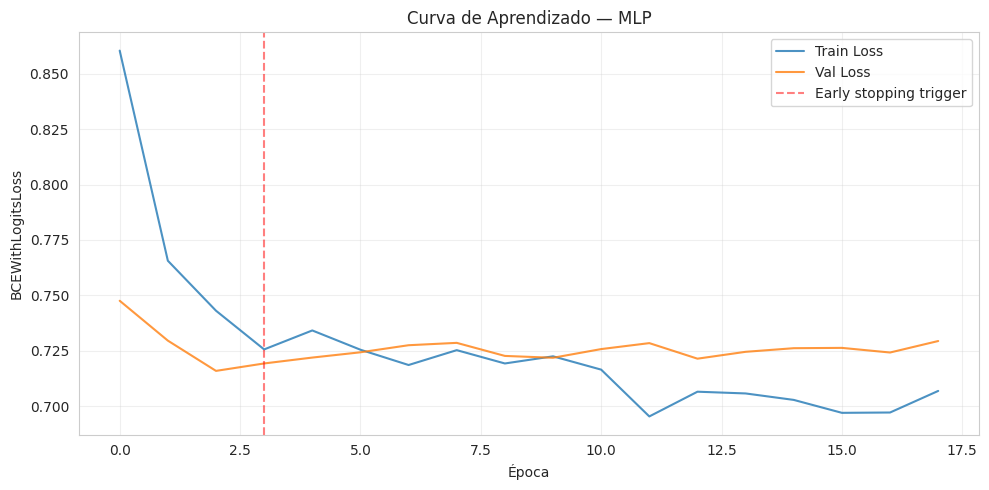

In [15]:
# Curva de aprendizado
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train Loss", alpha=0.8)
ax.plot(val_losses, label="Val Loss", alpha=0.8)
ax.axvline(len(train_losses) - PATIENCE, color="red", linestyle="--", alpha=0.5, label="Early stopping trigger")
ax.set_xlabel("Época")
ax.set_ylabel("BCEWithLogitsLoss")
ax.set_title("Curva de Aprendizado — MLP")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Avaliação do MLP no conjunto de teste

Usamos a mesma função `evaluate_model` dos baselines para garantir comparabilidade. Para isso, criamos um wrapper sklearn-compatible.

In [17]:
class PyTorchWrapper:
    """Wrapper para usar modelo PyTorch com evaluate_model (interface sklearn)."""

    def __init__(self, model, device, threshold=0.5):
        self.model = model
        self.device = device
        self.threshold = threshold

    def predict_proba(self, X):
        self.model.eval()
        if isinstance(X, pd.DataFrame):
            X = torch.tensor(X.values.astype(np.float32), dtype=torch.float32)
        X = X.to(self.device)
        with torch.no_grad():
            logits = self.model(X)
            probs = torch.sigmoid(logits).cpu().numpy()
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)


mlp_wrapper = PyTorchWrapper(model, device)

print("=" * 60)
print(" MLP (PyTorch)")
print("=" * 60)
mlp_metrics, mlp_cm = evaluate_model(mlp_wrapper, X_test_mlp, y_test_mlp)

 MLP (PyTorch)
              precision    recall  f1-score   support

   Sem churn       0.91      0.72      0.80      1035
   Com churn       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409

  ROC-AUC:  0.8449
  PR-AUC:   0.6543
  TP Custo churn evitado:  R$ 121,600
  FN Custo churn perdido:  R$ 35,000
  FP Custo falso positivo: R$ 29,100
  ROI Campanha:            R$ 92,500  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 57,500  (ganho_tp - custo_fp - perda_fn)


### Comparação: MLP vs. Baselines

In [18]:
# Tabela comparativa completa
all_metric_keys = list(dummy_metrics.keys())
resumo_final = pd.DataFrame({
    "Metrica": all_metric_keys,
    "DummyClassifier": [dummy_metrics[m] for m in all_metric_keys],
    "LogisticRegression": [lr_metrics[m] for m in all_metric_keys],
    "MLP": [mlp_metrics[m] for m in all_metric_keys],
})

# Identificar melhor modelo por métrica (exceto Dummy)
resumo_display = resumo_final.copy()
for col in ["DummyClassifier", "LogisticRegression", "MLP"]:
    resumo_display[col] = resumo_final.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

print("=" * 70)
print(" COMPARAÇÃO FINAL: Baselines vs. MLP")
print("=" * 70)
resumo_display

 COMPARAÇÃO FINAL: Baselines vs. MLP


,Metrica,DummyClassifier,LogisticRegression,MLP
0,accuracy,0.7346,0.7459,0.7438
1,f1_score,0.0000,0.6247,0.6275
2,precision,0.0000,0.5138,0.5109
3,recall,0.0000,0.7968,0.8128
4,roc_auc,0.5000,0.8473,0.8449
5,pr_auc,0.6327,0.6660,0.6543
6,custo_churn_evitado_BRL,R$ 0,"R$ 119,200","R$ 121,600"
7,custo_falso_positivo_BRL,R$ 0,"R$ 28,200","R$ 29,100"
8,custo_churn_perdido_BRL,"R$ 187,000","R$ 38,000","R$ 35,000"
9,roi_campanha_BRL,R$ 0,"R$ 91,000","R$ 92,500"


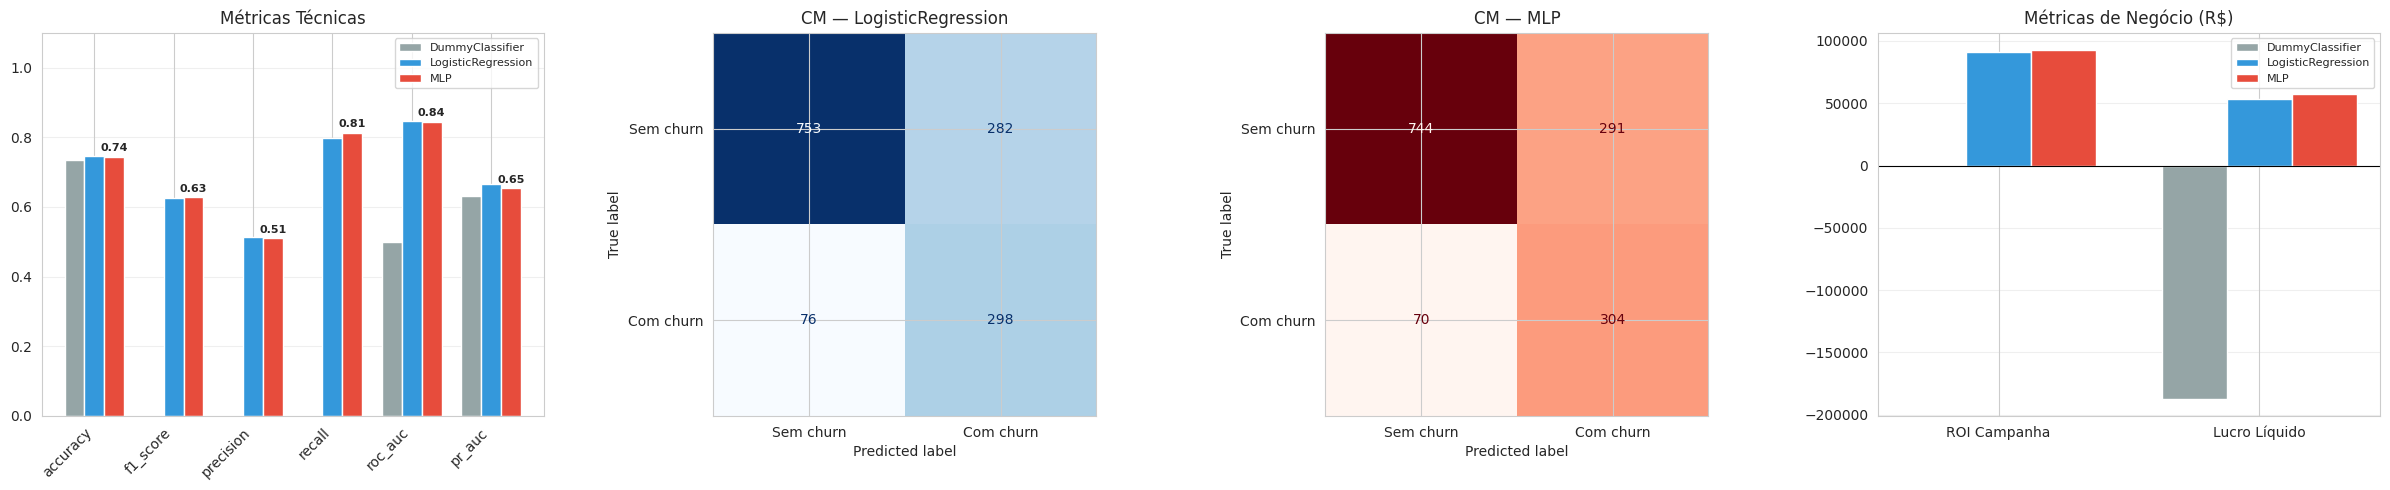

In [19]:
# Visualização comparativa — 3 modelos
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# --- 1. Métricas técnicas lado a lado ---
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]
mlp_vals = [mlp_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.25
axes[0].bar(x - width, dummy_vals, width, label="DummyClassifier", color="#95a5a6")
axes[0].bar(x, lr_vals, width, label="LogisticRegression", color="#3498db")
bars_mlp = axes[0].bar(x + width, mlp_vals, width, label="MLP", color="#e74c3c")
for bar in bars_mlp:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Métricas Técnicas")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# --- 2. Confusion Matrix — LR ---
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("CM — LogisticRegression")

# --- 3. Confusion Matrix — MLP ---
ConfusionMatrixDisplay(mlp_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[2], cmap="Reds", colorbar=False
)
axes[2].set_title("CM — MLP")

# --- 4. Métricas de negócio ---
biz_metrics = ["roi_campanha_BRL", "lucro_liquido_BRL"]
biz_labels = ["ROI Campanha", "Lucro Líquido"]
dummy_biz = [dummy_metrics[m] for m in biz_metrics]
lr_biz = [lr_metrics[m] for m in biz_metrics]
mlp_biz = [mlp_metrics[m] for m in biz_metrics]

x_biz = np.arange(len(biz_metrics))
axes[3].bar(x_biz - width, dummy_biz, width, label="DummyClassifier", color="#95a5a6")
axes[3].bar(x_biz, lr_biz, width, label="LogisticRegression", color="#3498db")
axes[3].bar(x_biz + width, mlp_biz, width, label="MLP", color="#e74c3c")
axes[3].set_xticks(x_biz)
axes[3].set_xticklabels(biz_labels)
axes[3].set_title("Métricas de Negócio (R$)")
axes[3].legend(fontsize=8)
axes[3].grid(axis="y", alpha=0.3)
axes[3].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

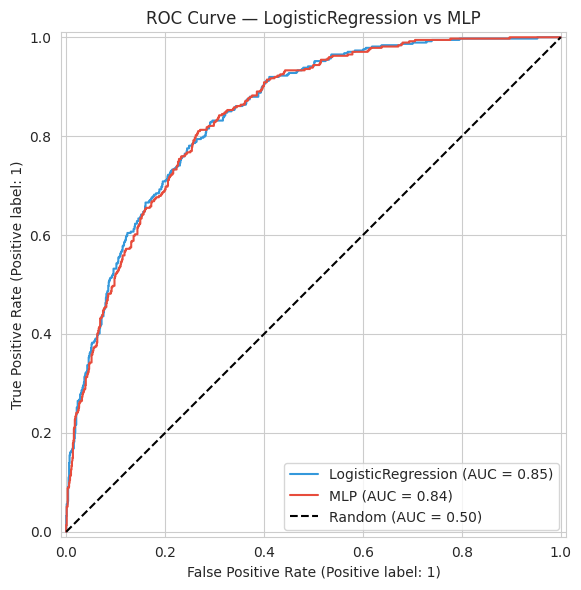

In [20]:
# ROC Curve — LR vs MLP
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name="LogisticRegression", color="#3498db")

# MLP ROC manual (wrapper não é sklearn estimator)
y_proba_mlp = mlp_wrapper.predict_proba(X_test_mlp)[:, 1]
from sklearn.metrics import RocCurveDisplay as RCD
RCD.from_predictions(y_test_mlp, y_proba_mlp, ax=ax, name="MLP", color="#e74c3c")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — LogisticRegression vs MLP")
ax.legend()
plt.tight_layout()
plt.show()

### Análise de Trade-off: Threshold vs. Custo

Variando o threshold de classificação para entender o trade-off entre falso positivo (custo de retenção desperdiçado) e falso negativo (churn perdido).

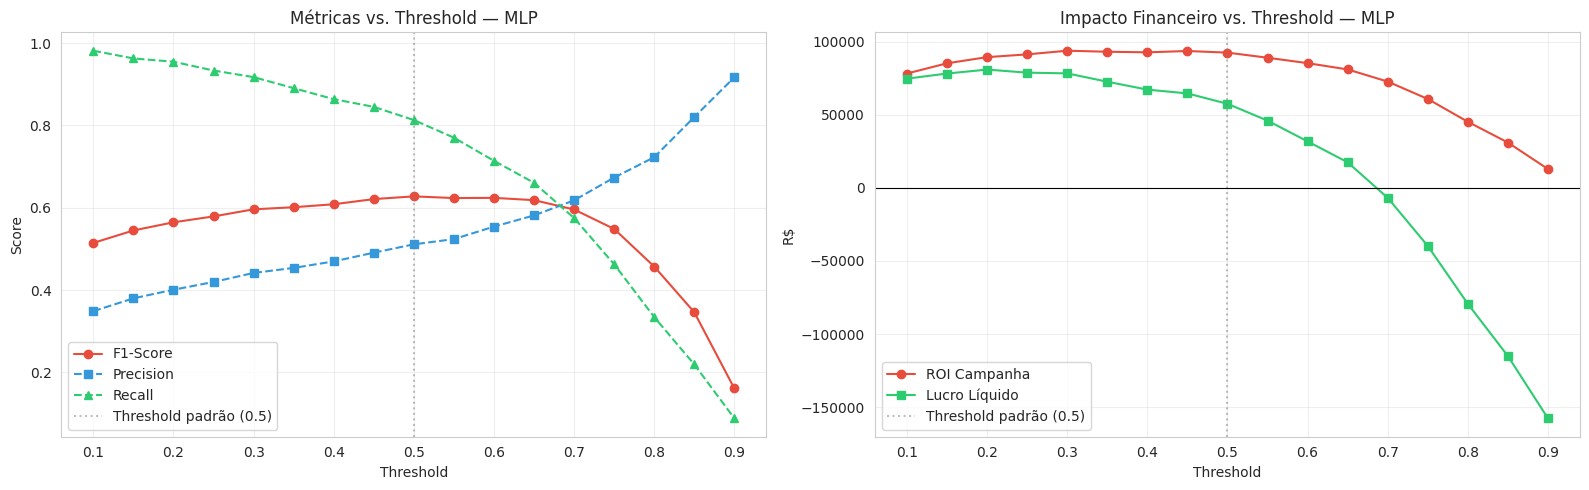


Threshold ótimo (lucro líquido): 0.20
  F1: 0.5644 | Precision: 0.4007 | Recall: 0.9545
  ROI Campanha: R$ 89,400
  Lucro Líquido: R$ 80,900


In [21]:
# Trade-off de custo por threshold — MLP
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

y_test_np = y_test_mlp.values if hasattr(y_test_mlp, "values") else y_test_mlp
y_proba_mlp_test = mlp_wrapper.predict_proba(X_test_mlp)[:, 1]

for t in thresholds:
    y_pred_t = (y_proba_mlp_test >= t).astype(int)
    cm_t = confusion_matrix(y_test_np, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    results.append({
        "threshold": t,
        "f1": f1_score(y_test_np, y_pred_t),
        "precision": precision_score(y_test_np, y_pred_t, zero_division=0),
        "recall": recall_score(y_test_np, y_pred_t),
        "roi_campanha": tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO) - fp * CUSTO_RETENCAO,
        "lucro_liquido": tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO) - fp * CUSTO_RETENCAO - fn * VALOR_CLIENTE_LTV,
    })

df_thresh = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Métricas técnicas vs threshold
axes[0].plot(df_thresh["threshold"], df_thresh["f1"], "o-", label="F1-Score", color="#e74c3c")
axes[0].plot(df_thresh["threshold"], df_thresh["precision"], "s--", label="Precision", color="#3498db")
axes[0].plot(df_thresh["threshold"], df_thresh["recall"], "^--", label="Recall", color="#2ecc71")
axes[0].axvline(0.5, color="gray", linestyle=":", alpha=0.5, label="Threshold padrão (0.5)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Métricas vs. Threshold — MLP")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Custo vs threshold
axes[1].plot(df_thresh["threshold"], df_thresh["roi_campanha"], "o-", label="ROI Campanha", color="#e74c3c")
axes[1].plot(df_thresh["threshold"], df_thresh["lucro_liquido"], "s-", label="Lucro Líquido", color="#2ecc71")
axes[1].axvline(0.5, color="gray", linestyle=":", alpha=0.5, label="Threshold padrão (0.5)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("R$")
axes[1].set_title("Impacto Financeiro vs. Threshold — MLP")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Threshold ótimo por lucro líquido
best_idx = df_thresh["lucro_liquido"].idxmax()
best_row = df_thresh.iloc[best_idx]
print(f"\nThreshold ótimo (lucro líquido): {best_row['threshold']:.2f}")
print(f"  F1: {best_row['f1']:.4f} | Precision: {best_row['precision']:.4f} | Recall: {best_row['recall']:.4f}")
print(f"  ROI Campanha: R$ {best_row['roi_campanha']:,.0f}")
print(f"  Lucro Líquido: R$ {best_row['lucro_liquido']:,.0f}")